In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import pairwise_distances

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [6]:
wine_data = load_wine()

wine_df = pd.DataFrame(
    wine_data.data,
    columns=wine_data.feature_names
)

actual_labels = wine_data.target

wine_df["actual_class"] = actual_labels

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,actual_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
# Dataset Preview
The Wine dataset contains chemical measurements for three wine categories. The actual class label is included only for evaluation and is not used during clustering.

In [7]:
profile_table = pd.DataFrame({
    "Dataset Detail": [
        "Total records",
        "Number of input features",
        "Number of actual classes",
        "Missing values"
    ],
    "Value": [
        wine_df.shape[0],
        len(wine_data.feature_names),
        len(np.unique(actual_labels)),
        wine_df.isnull().sum().sum()
    ]
})

profile_table

,Dataset Detail,Value
0,Total records,178
1,Number of input features,13
2,Number of actual classes,3
3,Missing values,0


In [8]:
wine_df.drop(columns=["actual_class"]).describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [ ]:
# Feature Review
The feature statistics show that wine attributes have different numerical ranges. Since clustering is distance-based, standardization is required before applying K-Means and K-Medoids.

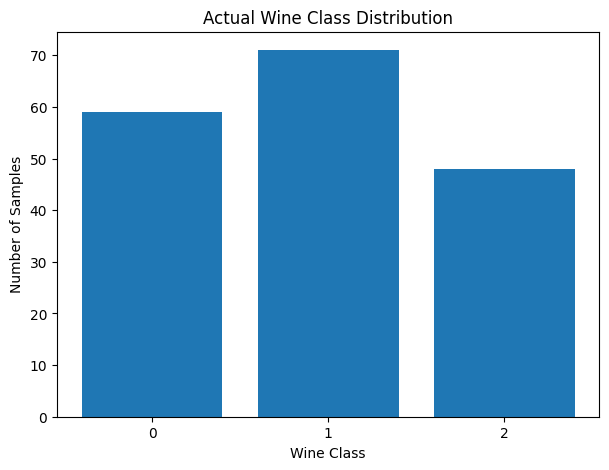

In [9]:
class_counts = pd.Series(actual_labels).value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.title("Actual Wine Class Distribution")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.show()

In [10]:
features_only = wine_df.drop(columns=["actual_class"])

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features_only)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features_only.columns
)

scaled_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [ ]:
# Standardization
Z-score normalization was applied so all features have comparable scale. This prevents features with larger numeric values from dominating the clustering process.

In [11]:
pca = PCA(n_components=2, random_state=42)

pca_values = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_values,
    columns=["PC1", "PC2"]
)

pca_df["actual_class"] = actual_labels

pca_df.head()

,PC1,PC2,actual_class
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


In [ ]:
# PCA Projection
PCA was used to reduce the 13-dimensional dataset into two components for visualization. The clustering models still use the standardized full feature set.

In [12]:
kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(scaled_features)

pd.Series(kmeans_labels).value_counts().sort_index()

0    65
1    51
2    62
Name: count, dtype: int64

In [13]:
kmeans_silhouette = silhouette_score(
    scaled_features,
    kmeans_labels
)

kmeans_ari = adjusted_rand_score(
    actual_labels,
    kmeans_labels
)

kmeans_results = pd.DataFrame({
    "Metric": ["Silhouette Score", "Adjusted Rand Index"],
    "K-Means Result": [kmeans_silhouette, kmeans_ari]
})

kmeans_results

,Metric,K-Means Result
0,Silhouette Score,0.284859
1,Adjusted Rand Index,0.897495


In [20]:
def manual_kmedoids(data, n_clusters=3, max_iter=100, random_state=42):
    np.random.seed(random_state)

    distance_matrix = pairwise_distances(data, metric="euclidean")

    medoid_indices = np.random.choice(
        data.shape[0],
        n_clusters,
        replace=False
    )

    for iteration in range(max_iter):
        distances_to_medoids = distance_matrix[:, medoid_indices]

        labels = np.argmin(
            distances_to_medoids,
            axis=1
        )

        new_medoid_indices = medoid_indices.copy()

        for cluster_id in range(n_clusters):
            cluster_points = np.where(labels == cluster_id)[0]

            if len(cluster_points) == 0:
                continue

            cluster_distances = distance_matrix[
                np.ix_(cluster_points, cluster_points)
            ]

            total_distances = cluster_distances.sum(axis=1)

            best_medoid_position = np.argmin(total_distances)

            new_medoid_indices[cluster_id] = cluster_points[
                best_medoid_position
            ]

        if np.array_equal(medoid_indices, new_medoid_indices):
            break

        medoid_indices = new_medoid_indices

    final_distances = distance_matrix[:, medoid_indices]

    final_labels = np.argmin(
        final_distances,
        axis=1
    )

    return final_labels, medoid_indices
print("Manual K-Medoids function created successfully.")

Manual K-Medoids function created successfully.


In [ ]:
# Manual K-Medoids Implementation
A manual K-Medoids function was used because the external `scikit-learn-extra` package was not compatible with the system environment. This implementation still follows the K-Medoids logic by selecting actual observations as medoids and assigning each sample to the nearest medoid.

In [21]:
kmedoids_labels, medoid_indices = manual_kmedoids(
    scaled_features,
    n_clusters=3,
    random_state=42
)

pd.Series(kmedoids_labels).value_counts().sort_index()

0    89
1    24
2    65
Name: count, dtype: int64

In [22]:
kmedoids_silhouette = silhouette_score(
    scaled_features,
    kmedoids_labels
)

kmedoids_ari = adjusted_rand_score(
    actual_labels,
    kmedoids_labels
)

kmedoids_results = pd.DataFrame({
    "Metric": ["Silhouette Score", "Adjusted Rand Index"],
    "K-Medoids Result": [kmedoids_silhouette, kmedoids_ari]
})

kmedoids_results

,Metric,K-Medoids Result
0,Silhouette Score,0.154764
1,Adjusted Rand Index,0.341266


In [23]:
comparison_table = pd.DataFrame({
    "Algorithm": ["K-Means", "K-Medoids"],
    "Silhouette Score": [
        kmeans_silhouette,
        kmedoids_silhouette
    ],
    "Adjusted Rand Index": [
        kmeans_ari,
        kmedoids_ari
    ]
})

comparison_table

,Algorithm,Silhouette Score,Adjusted Rand Index
0,K-Means,0.284859,0.897495
1,K-Medoids,0.154764,0.341266


In [ ]:
# Comparison
The comparison table evaluates both algorithms using the same standardized dataset. A higher Silhouette Score indicates better internal cluster structure, while a higher ARI indicates stronger agreement with the actual wine classes.

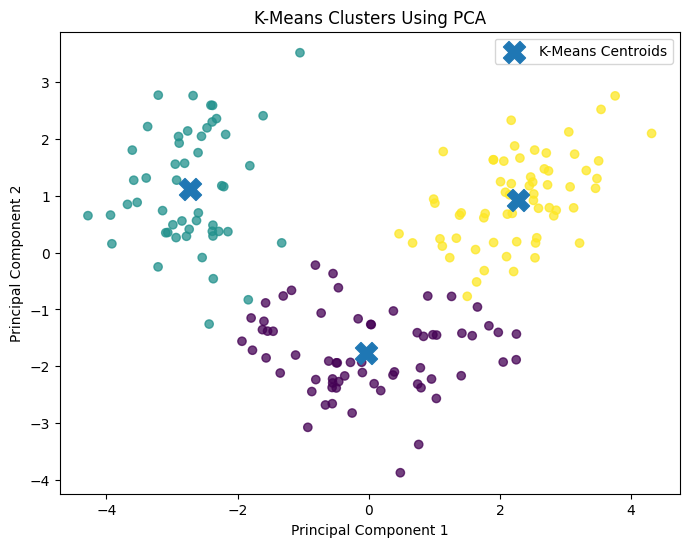

In [24]:
kmeans_centers_pca = pca.transform(
    kmeans_model.cluster_centers_
)

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=kmeans_labels,
    alpha=0.75
)

plt.scatter(
    kmeans_centers_pca[:, 0],
    kmeans_centers_pca[:, 1],
    marker="X",
    s=250,
    label="K-Means Centroids"
)

plt.title("K-Means Clusters Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

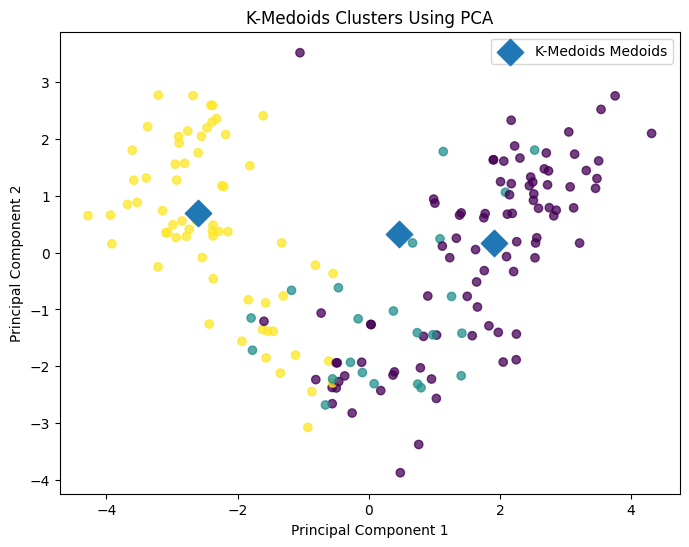

In [25]:
medoid_points = scaled_features[medoid_indices]

medoids_pca = pca.transform(medoid_points)

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=kmedoids_labels,
    alpha=0.75
)

plt.scatter(
    medoids_pca[:, 0],
    medoids_pca[:, 1],
    marker="D",
    s=180,
    label="K-Medoids Medoids"
)

plt.title("K-Medoids Clusters Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [26]:
best_model = comparison_table.sort_values(
    by=["Adjusted Rand Index", "Silhouette Score"],
    ascending=False
).iloc[0]

final_decision = pd.DataFrame({
    "Selected Algorithm": [best_model["Algorithm"]],
    "Silhouette Score": [best_model["Silhouette Score"]],
    "Adjusted Rand Index": [best_model["Adjusted Rand Index"]],
    "Selection Reason": [
        "Selected based on stronger agreement with actual labels and cluster separation"
    ]
})

final_decision

,Selected Algorithm,Silhouette Score,Adjusted Rand Index,Selection Reason
0,K-Means,0.284859,0.897495,Selected based on stronger agreement with actu...


In [ ]:
# Analysis

This lab compared K-Means and K-Medoids clustering using the Wine dataset. Since the dataset contains chemical features with different scales, Z-score standardization was applied before clustering. This step was important because both algorithms depend on distance calculations.

K-Means used calculated centroids to represent each cluster, while K-Medoids used actual wine samples as cluster centers. This difference is important because K-Medoids can be more resistant to unusual observations, while K-Means is often efficient when clusters are compact and clean.

The clustering results were evaluated using Silhouette Score and Adjusted Rand Index. The Silhouette Score measured how well-separated the clusters were, while ARI compared the generated clusters with the actual wine classes.

The PCA visualizations showed how both algorithms grouped the wine samples in two-dimensional space. The cluster centers were also marked to make the plots easier to interpret.

Overall, the better algorithm should be selected based on the higher evaluation scores. K-Means is generally preferable for clean and compact datasets, while K-Medoids may be preferable when the dataset contains noise or when real representative data points are desired as cluster centers.